In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/telco_processed.csv')
print(df.shape)

(7043, 24)


In [3]:
X = df.drop('Churn', axis=1)
y = df['Churn']
print(X.shape, y.shape)

(7043, 23) (7043,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (5634, 23)
Test size: (1409, 23)


In [5]:
print(f"Train churn rate: {y_train.mean():.4f}")
print(f"Test churn rate: {y_test.mean():.4f}")

Train churn rate: 0.2654
Test churn rate: 0.2654


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling done")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Scaling done
X_train_scaled shape: (5634, 23)
X_test_scaled shape: (1409, 23)


In [7]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8419


In [8]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8290


In [9]:
# XGBoost
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.58      0.50      0.54       374

    accuracy                           0.77      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.77      0.77      1409

ROC-AUC: 0.8224


In [10]:
lr_balanced = LogisticRegression(
    random_state=42, 
    max_iter=1000,
    class_weight='balanced'
)
lr_balanced.fit(X_train_scaled, y_train)
y_pred_lr_b = lr_balanced.predict(X_test_scaled)
y_prob_lr_b = lr_balanced.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression (Balanced) ===")
print(classification_report(y_test, y_pred_lr_b))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr_b):.4f}")

=== Logistic Regression (Balanced) ===
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8415


In [11]:
rf_balanced = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight='balanced'
)
rf_balanced.fit(X_train_scaled, y_train)
y_pred_rf_b = rf_balanced.predict(X_test_scaled)
y_prob_rf_b = rf_balanced.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest (Balanced) ===")
print(classification_report(y_test, y_pred_rf_b))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf_b):.4f}")

=== Random Forest (Balanced) ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.80      0.79      1409

ROC-AUC: 0.8274


In [12]:
xgb_balanced = xgb.XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])
)
xgb_balanced.fit(X_train_scaled, y_train)
y_pred_xgb_b = xgb_balanced.predict(X_test_scaled)
y_prob_xgb_b = xgb_balanced.predict_proba(X_test_scaled)[:, 1]

print("=== XGBoost (Balanced) ===")
print(classification_report(y_test, y_pred_xgb_b))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb_b):.4f}")

=== XGBoost (Balanced) ===
              precision    recall  f1-score   support

           0       0.87      0.80      0.84      1035
           1       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409

ROC-AUC: 0.8210


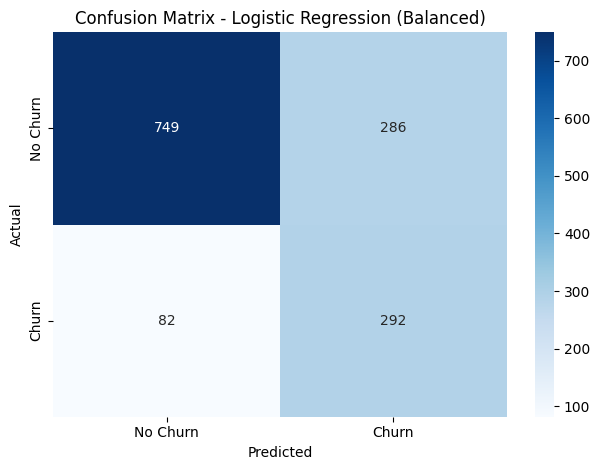

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr_b)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Logistic Regression (Balanced)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png')
plt.show()

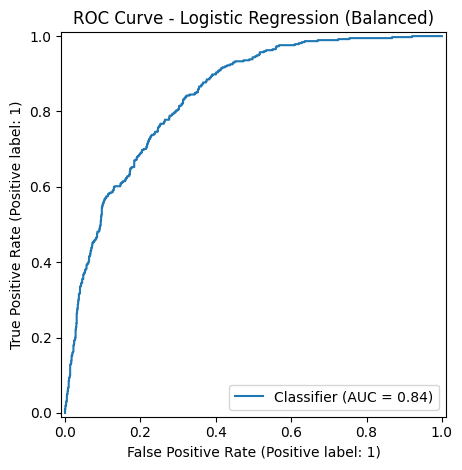

In [14]:
# ROC Curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prob_lr_b)
plt.title('ROC Curve - Logistic Regression (Balanced)')
plt.tight_layout()
plt.savefig('../reports/roc_curve.png')
plt.show()

In [15]:
import joblib

# Save model
joblib.dump(lr, '../models/churn_model.pkl')

# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')

print("Model and scaler saved!")

Model and scaler saved!


In [16]:
print(list(X.columns))


['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [17]:
joblib.dump(list(X.columns), '../models/feature_names.pkl')

['../models/feature_names.pkl']